# TP Initiation Calcul Scientifique

### Étape 1 : Choisir les conditions.

Considérons, ici, que l'on cherche une fonction $u$ vérifiant:
$
\begin{cases}
-\Delta u(x,y) = f(x,y) \quad \forall (x,y)\in ]0,L[ \times ]0,H[\\
\partial_yu(x,0) = 0 \quad \forall x\in ]0,L[\\
u(x,Y) = 0 \quad \forall x\in ]0,L[\\
\partial_xu(0,y) = 0 \quad \forall y\in ]0,H[\\
u(X,y) = 0 \quad \forall y\in ]0,H[\\
\end {cases}
$

Les bord haut et droit vérifient une condition de Dirichlet et les bords bas et gauche une condition de Neumann.

### Étape 2 : La discrétisation.

In [64]:
from IPython.display import display, Latex
from IPython.core.display import HTML
%reset -f
%matplotlib inline
%autosave 300

Autosaving every 300 seconds


In [65]:
from scipy.sparse import lil_matrix, csr_matrix
from scipy.sparse.linalg import spsolve
from scipy.sparse import spdiags
import sympy as sy
from numpy import linspace, ones
import numpy as np
from matplotlib import pyplot as plt
from matplotlib.pylab import *
from time import time
from mpl_toolkits import mplot3d


Nous considérons la discrétisation suivante du domaine.

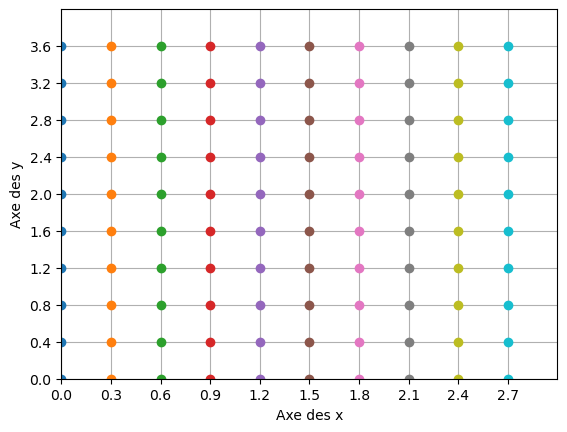

In [66]:
L = 3
H = 4
Nx = 10
Ny = 10
dx=L/(Nx)
dy=H/(Ny)
x=linspace(0,L-dx,Nx)
y=linspace(0,H-dy,Ny)

inconnues_x, inconnues_y = np.meshgrid(x, y)
plt.xlim(0,L)
plt.ylim(0,H)
plt.plot(inconnues_x, inconnues_y, 'o')

# Ajouter des labels
xlabel('Axe des x')
ylabel('Axe des y')
xticks(np.arange(0, L, dx))
yticks(np.arange(0, H, dy))
grid(True)

plt.show()

### On voit bien que nos points suivent bien les conditions de notre problème avec des points de discrétisation sur les bords bas et gauche signifiant des conditions de Neumann mais pas de points de discrétisation sur les bords haut et droit signifiant des conditions de Dirichlet.

### Étape 3 : Construction de la matrice d'aproximation du problème par différence centrée d'ordre 2.
On choisit ici une méthode algorithmique pour construire notre matrice, pour un code plus concis on peut le faire en construisant les diagonales avec spdiags si on a bien compris la structure de la matrice et du problème.


In [67]:
def Matrice_creuse(Nx, Ny):
    # grille pour Dirichlet bord haut et droit.
    # Neumann pour bord gauche et bas
    
    dx=L/(Nx)
    dy=H/(Ny)
    
    #liste des numéros des noeuds presentants 4 voisins faisant partie des noeuds où la solution est inconnue
    Linterieur = []
    for i in range(1, Nx-1):
        for j in range(1, Ny-1):
            Linterieur.append(i + j*Nx)
            

    
    #liste des noeuds du bas sauf coins
    Lbas=[i for i in range(1,Nx-1)]
    #liste des noeuds du haut sauf coins
    Lhaut=[i for i in range(Nx*(Ny-1)+1,Nx*Ny-1)]
    #liste des noeuds de gauche sauf coins
    Lgauche=[i*Nx for i in range(1,Ny-1)]
    #liste des noeuds de droite sauf coins
    Ldroite=[i*Nx-1 for i in range(2,Ny)]
    
    
    A=lil_matrix((Nx*Ny,Nx*Ny))
    #construction de la diagonale de A
    for k in range(Nx*Ny):
        A[k,k]=2/dx**2+2/dy**2
    #construction de la matrice A pour les noeuds presentants 4 voisins inconnus
    for k in Linterieur:
        A[k,k+1]=-1/dx**2
        A[k,k-1]=-1/dx**2
        A[k,k+Nx]=-1/dy**2
        A[k,k-Nx]=-1/dy**2
    # contribution pour les noeuds du bas
    for k in Lbas:
        A[k,k+1]=-1/dx**2
        A[k,k-1]=-1/dx**2
        A[k,k+Nx]=-2/dy**2
    # contribution pour les noeuds du haut
    for k in Lhaut:
        A[k,k+1]=-1/dx**2
        A[k,k-1]=-1/dx**2
        A[k,k-Nx]=-1/dy**2
    # contribution pour les noeuds de gauche
    for k in Lgauche:
        A[k,k+1]=-2/dx**2
        A[k,k+Nx]=-1/dy**2
        A[k,k-Nx]=-1/dy**2
    # contribution pour les noeuds de droite
    for k in Ldroite:
        A[k,k-1]=-1/dx**2
        A[k,k+Nx]=-1/dy**2
        A[k,k-Nx]=-1/dy**2
    #coin bas gauche
    k=0
    A[k,k+1]=-2/dx**2
    A[k,k+Nx]=-2/dy**2
    #coin bas droite
    k=Nx-1
    A[k,k-1]=-1/dx**2
    A[k,k+Nx]=-2/dy**2
    #coin haut gauche
    k=Nx*(Ny-1)
    A[k,k+1]=-2/dx**2
    A[k,k-Nx]=-1/dy**2
    #coin haut droite
    k=Nx*Ny-1
    A[k,k-1]=-1/dx**2
    A[k,k-Nx]=-1/dy**2
    
    A= csr_matrix(A)

    return A


In [68]:
second_membre = lambda Nx, Ny : ones(Nx*Ny)

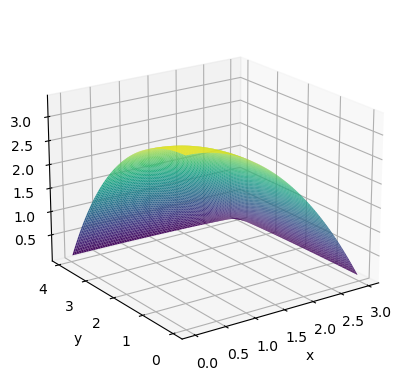

In [69]:
L = 3
H = 4
Nx = 100
Ny = 100
dx=L/(Nx)
dy=H/(Ny)
x=linspace(0,L-dx,Nx)
y=linspace(0,H-dy,Ny)

U = spsolve(Matrice_creuse(Nx, Ny) , second_membre(Nx, Ny))
uu=U.reshape((Ny,Nx))

from mpl_toolkits import mplot3d
xx,yy = meshgrid(x, y)
ax = axes(projection='3d')
ax.plot_surface(xx, yy, uu, rstride=1, cstride=1,
                cmap='viridis', edgecolor='none');
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('u');
ax.view_init(20, -125)
plt.show()

On voit bien les bords haut et droit être nuls et la solution qui "s'applatit" au coin bas gauche à cause de la dérivée normale nulle aux bords gauche et bas. La solution à l'air correcte à vu d'oeil mais cela ne suffit pas il faut le prouver.

# Étape 4 : Choisir l'expression analytique de $u(x,y)$ en déduire la fonction exacte $u$ et le $-\Delta u$  nommé $f$.

In [70]:
# fct exacte u
fct_u = lambda x,y : x*x*y*y*np.sin(H-y)*np.sin(x-L)

# Pour avoir l'expression du Laplacien et la mettre dans la fonction
#f=-sy.diff(u, x, 2) - sy.diff(u, y, 2)
#display(f)


f = lambda x,y : -x**2*(y**2*np.sin(y - 4) - 4*y*np.cos(y - 4) - 2*np.sin(y - 4))*np.sin(x - 3) - y**2*(x**2*np.sin(x - 3) - 4*x*np.cos(x - 3) - 2*np.sin(x - 3))*np.sin(y - 4)


# Vérification des conditions.
x,y = sy.symbols('x y')
u = x*x*y*y*sy.sin(H-y)*sy.sin(x-L)
dxu=sy.diff(u,x)
dyu=sy.diff(u,y)
display(dyu.subs(y,0))
display(dyu.subs(x,0))


0

0

### La fonction $u$ est bien nulle lorsque $x = L$ et $y = H$ (nos condition de Dirichlet) et la dérivée normale lorsque $x = 0$ et $y = 0$ est bien nulle aussi (nos conditions de Neumann).

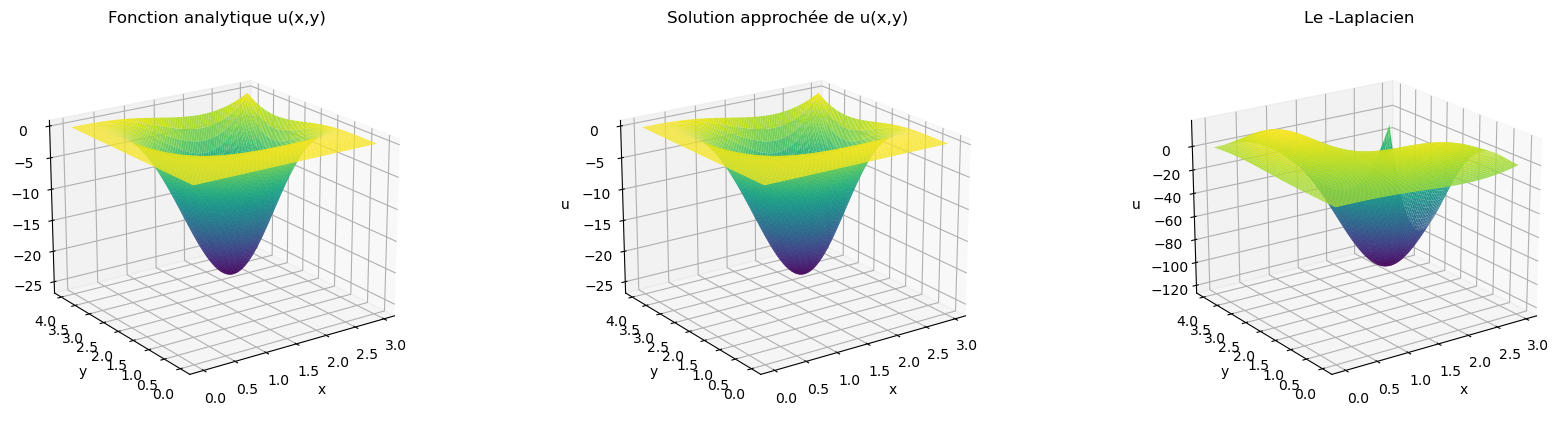

In [71]:
L = 3
H = 4
Nx = 100
Ny = 100
dx=L/(Nx)
dy=H/(Ny)
x=linspace(0,L-dx,Nx)
y=linspace(0,H-dy,Ny)
xx,yy = meshgrid(x, y)



# Création de la figure avec trois sous-graphiques
fig = plt.figure(figsize=(20, 5))

# 1er graphique : Fonction analytique
g1 = fig.add_subplot(1, 3, 1, projection='3d')
g1.plot_surface(xx, yy, fct_u(xx, yy), rstride=1, cstride=1, cmap='viridis', edgecolor='none')
g1.set_xlabel('x')
g1.set_ylabel('y')
g1.set_zlabel('u')
g1.set_title('Fonction analytique u(x,y)')
g1.view_init(20, -125)

# 2e graphique : Solution approchée
U = spsolve(Matrice_creuse(Nx, Ny) , f(xx, yy).flatten())
uu=U.reshape((Ny,Nx))
g2 = fig.add_subplot(1, 3, 2, projection='3d')
g2.plot_surface(xx, yy, uu, rstride=1, cstride=1, cmap='viridis', edgecolor='none')
g2.set_xlabel('x')
g2.set_ylabel('y')
g2.set_zlabel('u')
g2.set_title('Solution approchée de u(x,y)')
g2.view_init(20, -125)

# 3e graphique : Laplacien
g3 = fig.add_subplot(1, 3, 3, projection='3d')
g3.plot_surface(xx, yy, f(xx, yy), rstride=1, cstride=1, cmap='viridis', edgecolor='none')
g3.set_xlabel('x')
g3.set_ylabel('y')
g3.set_zlabel('u')
g3.set_title('Le -Laplacien')
g3.view_init(20, -125)

# Espacement entre les sous-graphiques
plt.subplots_adjust(wspace=0.4)
plt.show()



# Étape 5 : Comparer la solution exacte et l'approximation.

On sait désormais l'expression de $f$. On va alors construire cette fonction et définir la solution exacte. En définissant l'erreur entre la solution exacte et approchée, pour la norme de notre choix, comme une fonction python qui dépend de la taille de la discrétisation, on pourra alors calculer aisément l'erreur pour plusieurs discrétisation. La fonction construite sera également paramètrée par la fonction , (solution exacte) et un entier qui caractérise la norme choisie.

In [72]:
# La fonction pour calculer l'erreur
def erreur_Dirchlethd_Neumannbg(Nx, Ny, u, f, p):
    """
    N est le nombre de points de discrétisation
    u et f les fonctions passées en argumennt, on pourra en changer 
    en definissant d'autres fonctions
    p est l'entier pour la norme l^p
    """

    dx=L/(Nx)
    dy=H/(Ny)
    x=linspace(0,L-dx,Nx)
    y=linspace(0,H-dy,Ny)
    xx,yy = meshgrid(x, y)
    F = f(xx, yy).flatten()
   

    U=spsolve(Matrice_creuse(Nx, Ny), F)
    
    err = []
    #le vecteur erreur err
    for j in range(Ny):
        for i in range(Nx):
            err.append(abs(U[int(i+j*Nx)] - u(x[i], y[j])))
            
    norm_err = sum([ei**p for ei in err])**(1/p)
    norm_U = sum([abs(ui)**p for ui in U])**(1/p)
    
    return norm_err/norm_U
print(erreur_Dirchlethd_Neumannbg(200, 200,fct_u, f, 2))

2.834240496818087e-05


# Étape 6 : Établir la convergence (ordre 2) en liant $dx$ et $dy$. 

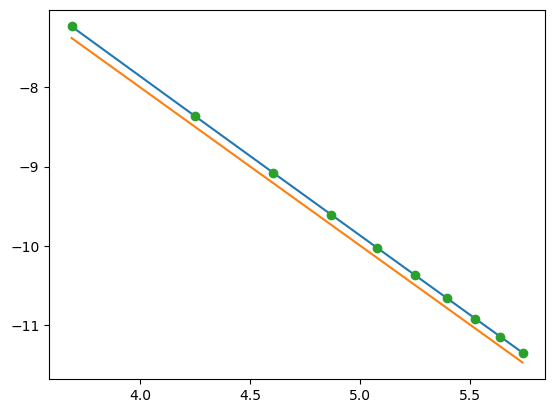

L'ordre de la méthode en h est : 2.0099622559816535


In [73]:

N_tab = []
error_tab = []


for N in range(40,311,30):
    Nbx = N
    Nby = N
    

    l = L/(Nbx)
    h = H/(Nby)
    
    x=linspace(0,L-l,Nbx)
    y=linspace(0,H-h,Nby)
    
    error_tab.append(erreur_Dirchlethd_Neumannbg(Nbx, Nby,fct_u, f, 2))
    N_tab.append(N)

N_tab = np.array(N_tab, dtype=float)
error_tab = np.array(error_tab, dtype=float)
plt.plot(np.log(N_tab),np.log(error_tab),np.log(N_tab),-2*np.log(N_tab))
plt.plot(np.log(N_tab),np.log(error_tab),'o')


plt.show()
print("L'ordre de la méthode en h est :",-polyfit(np.log(N_tab),np.log(error_tab), 1)[0])


Comme l'odre de la méthode est significativement proche de 2, on peut en conclure que la méthode converge vers la fonction exacte $u(x;y)$.

# Pour aller plus loin : Étendre le problème aux conditions limites inhomogènes en détaillant la construction du vecteur second membre.